In [193]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,ConfusionMatrixDisplay
import numpy as np

In [194]:
!pip install xlrd

In [195]:
df=pd.read_excel('c:/data/sepsis.Xls')
df.shape

(106, 6)

In [196]:
df.describe()

,Shock,Malnutrition,Alcoholism,Age,Infection,Death
count,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000
mean,0.094340,0.301887,0.207547,51.283019,0.132075,0.198113
std,0.293689,0.461257,0.407477,20.787705,0.340181,0.400471
min,0.000000,0.000000,0.000000,17.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,33.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,52.500000,0.000000,0.000000
75%,0.000000,1.000000,0.000000,68.750000,0.000000,0.000000
max,1.000000,1.000000,1.000000,94.000000,1.000000,1.000000


In [197]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106 entries, 0 to 105
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Shock         106 non-null    int64
 1   Malnutrition  106 non-null    int64
 2   Alcoholism    106 non-null    int64
 3   Age           106 non-null    int64
 4   Infection     106 non-null    int64
 5   Death         106 non-null    int64
dtypes: int64(6)
memory usage: 5.1 KB


In [198]:
df.value_counts()

Shock  Malnutrition  Alcoholism  Age  Infection  Death
0      0             0           20   0          0        3
                                 22   0          0        3
                                 36   0          0        3
                                 80   0          0        3
                                 26   0          0        2
                                                         ..
1      1             0           44   0          0        1
                                 57   0          1        1
                                 60   1          1        1
                                 70   0          1        1
                                 76   0          1        1
Name: count, Length: 87, dtype: int64

In [199]:
df.head()

,Shock,Malnutrition,Alcoholism,Age,Infection,Death
0,0,0,0,56,0,0
1,0,0,0,80,0,0
2,0,0,0,61,0,0
3,0,0,0,26,0,0
4,0,0,0,53,0,0


In [200]:
df.tail()

,Shock,Malnutrition,Alcoholism,Age,Infection,Death
101,0,1,1,49,0,0
102,0,0,0,25,0,0
103,1,1,0,44,0,0
104,0,0,1,56,0,0
105,0,1,1,42,0,0


In [201]:
df.Death.value_counts()

Death
0    85
1    21
Name: count, dtype: int64

In [202]:
X=df.iloc[ : ,:-1]
y=df['Death']


In [203]:
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=10,test_size=22)
X_train.shape,X_test.shape

((84, 5), (22, 5))

In [230]:
model=LogisticRegression()
model.fit(X,y)

LogisticRegression()

In [231]:
w,b=model.coef_[0],model.intercept_
w,b

(array([1.69729535, 0.68386267, 1.65527581, 0.06035376, 1.25886629]),
 array([-6.18968313]))

In [232]:
y_predict= X.dot(w)+b
p = 1/(1+np.exp(-y_predict))
np.array([1 if i>= 0.5 else 0 for i in p])

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0])

In [233]:
model.predict(X)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0])

In [234]:
model.predict_proba(X)[:10]


array([[0.94320701, 0.05679299],
       [0.79598433, 0.20401567],
       [0.924708  , 0.075292  ],
       [0.99024802, 0.00975198],
       [0.95216288, 0.04783712],
       [0.56341755, 0.43658245],
       [0.99276996, 0.00723004],
       [0.59145855, 0.40854145],
       [0.93988618, 0.06011382],
       [0.71482507, 0.28517493]])

In [235]:
p[:10]

0    0.056793
1    0.204016
2    0.075292
3    0.009752
4    0.047837
5    0.436582
6    0.007230
7    0.408541
8    0.060114
9    0.285175
dtype: float64

In [239]:
X.Age.describe()

count    106.000000
mean      51.283019
std       20.787705
min       17.000000
25%       33.000000
50%       52.500000
75%       68.750000
max       94.000000
Name: Age, dtype: float64

In [245]:
p1= []
for i in range (15,96):
    y_predict = 1*w[0] + 1*w[1] + 1*w[2] + i*w[3] + 1*w[4] + b
    p =1/(1+np.exp(-y_predict))
    p1.append(p)
    
p1[:5]   

[array([0.5027308]),
 array([0.51781173]),
 array([0.53286027]),
 array([0.54784926]),
 array([0.56275196])]

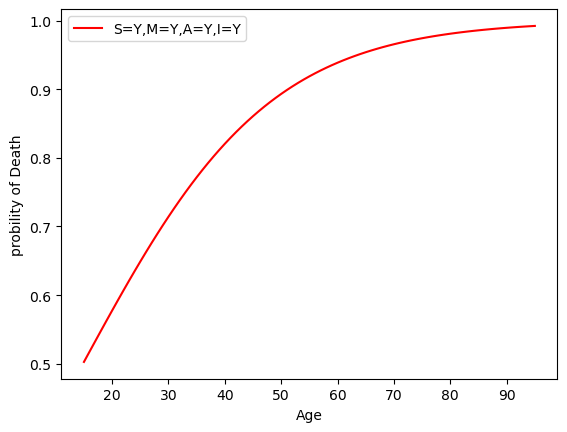

In [252]:
plt.plot(range(15,96),p1,c='red',label='S=Y,M=Y,A=Y,I=Y')
plt.legend()
plt.xlabel('Age')
plt.ylabel('probility of Death')
plt.show()

In [257]:
p3= []
for i in range (15,96):
    y_predict = 1*w[0] + 0*w[1] + 0*w[2] + i*w[3] + 1*w[4] + b
    p =1/(1+np.exp(-y_predict))
    p3.append(p)
    
p3[:5]   

[array([0.088813]),
 array([0.09381987]),
 array([0.09907832]),
 array([0.10459748]),
 array([0.11038641])]

In [258]:
p4= []
for i in range (15,96):
    y_predict = 0*w[0] + 0*w[1] + 1*w[2] + i*w[3] + 1*w[4] + b
    p =1/(1+np.exp(-y_predict))
    p4.append(p)
    
p4[:5]   

[array([0.08547079]),
 array([0.09030792]),
 array([0.09539026]),
 array([0.10072694]),
 array([0.1063271])]

In [261]:
p5= []
for i in range (15,96):
    y_predict = 0*w[0] + 0*w[1] + 1*w[2] + i*w[3] + 0*w[4] + b
    p =1/(1+np.exp(-y_predict))
    p5.append(p)
    
p5[:5]   

[array([0.02585387]),
 array([0.0274182]),
 array([0.02907435]),
 array([0.03082737]),
 array([0.03268253])]

In [262]:
p6= []
for i in range (15,96):
    y_predict = 0*w[0] + 0*w[1] + 0*w[2] + i*w[3] + 0*w[4] + b
    p =1/(1+np.exp(-y_predict))
    p6.append(p)
    
p6[:5]

[array([0.00504461]),
 array([0.00535677]),
 array([0.00568813]),
 array([0.00603986]),
 array([0.00641321])]

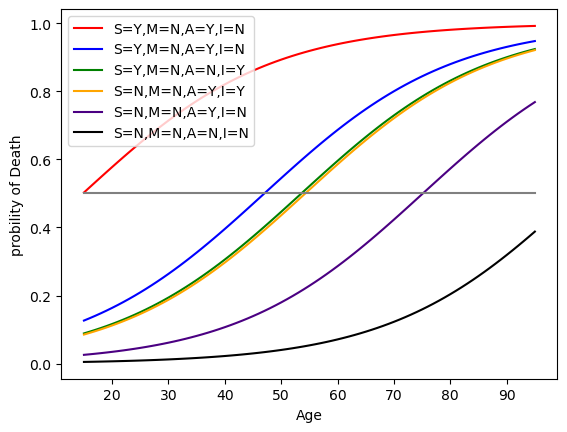

In [265]:
plt.plot(range(15,96),p1,c='red',label='S=Y,M=N,A=Y,I=N')
plt.plot(range(15,96),p2,c='blue',label='S=Y,M=N,A=Y,I=N')
plt.plot(range(15,96),p3,c='green',label='S=Y,M=N,A=N,I=Y')
plt.plot(range(15,96),p4,c='orange',label='S=N,M=N,A=Y,I=Y')
plt.plot(range(15,96),p5,c='indigo',label='S=N,M=N,A=Y,I=N')
plt.plot(range(15,96),p6,c='black',label='S=N,M=N,A=N,I=N')
plt.plot([15,95],[0.5,0.5],c='gray')
plt.legend()
plt.xlabel('Age')
plt.ylabel('probility of Death')
plt.show()